# XUVInt: интерпретируемые модели

Отдельный ноутбук, сфокусированный на **одном таргете — `XUVInt`** (поток
ионизующего излучения звезды), с упором на **интерпретируемость**: каждая
модель здесь позволяет объяснить, *почему* выдан такой ответ.

`XUVInt` — самый трудный из таргетов: он вырожден с `Helium` (разные пары
дают почти одинаковый профиль). Поэтому, как и в основном решении, используем
**протокол best-of-5** (модель возвращает 5 кандидатов, берётся лучший) —
он честно отражает многозначность обратной задачи и сравним с публикацией
(20.4% MAPE) и нашим лучшим DL (best-of-5 ≈ 9.8%).

Интерпретируемые кандидаты:
1. **k ближайших соседей** — «покажи 5 обучающих профилей, максимально похожих
   на данный, и верни их XUV». Предельно прозрачно: ответ = ответы соседей.
2. **Квантильная регрессия (XGBoost)** — 5 квантилей условного распределения
   XUV как 5 кандидатов; важности признаков объясняют вклад формы профиля.
3. **Символьная регрессия / одно дерево** — явная формула или дерево решений.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from scipy.spatial.distance import cdist

DATA_DIR = "new_dataset_V3"
GRID = np.arange(-5.0, 5.0 + 1e-9, 0.1)
profiles, targets = [], []
for name in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, name)
    if not os.path.isdir(path):
        continue
    params = {}
    with open(os.path.join(path, "parameters.txt")) as f:
        for line in f:
            p = line.split()
            if len(p) >= 2:
                params[p[0]] = p[1]
    arr = np.loadtxt(os.path.join(path, "Absorption.dat"), skiprows=1)
    if arr[-1, 0] - arr[0, 0] < 5:
        continue
    profiles.append(np.interp(GRID, arr[:, 0], arr[:, 1], left=0, right=0))
    targets.append([float(params["XUVInt"]), float(params["Helium"]),
                    float(params["Msw"]), int(params["H2a"])])
profiles = np.array(profiles, dtype=np.float32)
targets = np.array(targets)
y_xuv = np.log10(targets[:, 0])            # предсказываем log10(XUVInt)
y_cls = targets[:, 3].astype(int)
tr, va = train_test_split(np.arange(len(profiles)), test_size=0.2,
                          random_state=42, stratify=y_cls)
xuv_true = 10 ** y_xuv[va]


def mape_xuv(pred_log_single):
    return 100 * np.mean(np.abs(10**pred_log_single - xuv_true) / xuv_true)


def best_of_k(cand_log):                   # cand_log: (Nval, k) в log10
    return 100 * np.mean(
        np.abs(10**cand_log - xuv_true[:, None]).min(1) / xuv_true)


print("профилей:", len(profiles), " train:", len(tr), " val:", len(va))

профилей: 613  train: 490  val: 123


## 1. Признаки и представления профиля

Физически осмысленные признаки (интерпретируемые) и PCA-16 лог-профиля
(компактное представление формы для kNN).

In [2]:
FEATURE_NAMES = ["peak", "v_peak", "ew", "fwhm", "asym", "mean_v",
                 "sigma_v", "width10", "core_to_wing"]


def features(a):
    peak = a.max()
    v_peak = GRID[a.argmax()]
    ew = np.trapz(a, GRID)
    above = a >= peak / 2
    fwhm = GRID[above][-1] - GRID[above][0] if above.any() else 0.0
    blue = np.trapz(a[GRID < 0], GRID[GRID < 0])
    red = np.trapz(a[GRID > 0], GRID[GRID > 0])
    asym = (blue - red) / (blue + red + 1e-12)
    mean_v = np.trapz(GRID * a, GRID) / (ew + 1e-12)
    var_v = np.trapz((GRID - mean_v) ** 2 * a, GRID) / (ew + 1e-12)
    w10 = a >= 0.1 * peak
    width10 = GRID[w10][-1] - GRID[w10][0] if w10.any() else 0.0
    ctw = a[np.abs(GRID) <= 1].sum() / (a[np.abs(GRID) > 2].sum() + 1e-12)
    return [peak, v_peak, ew, fwhm, asym, mean_v, np.sqrt(var_v), width10, ctw]


X = np.array([features(p) for p in profiles])

log_prof = np.log10(np.clip(profiles, 1e-7, None))
mu = log_prof[tr].mean(0)
_, _, Vt = np.linalg.svd(log_prof[tr] - mu, full_matrices=False)
Z = (log_prof - mu) @ Vt[:16].T
Z = (Z - Z[tr].mean(0)) / Z[tr].std(0)
print("признаков:", X.shape[1], " PCA-компонент:", Z.shape[1])

признаков: 9  PCA-компонент: 16


## 2. Модель 1 — k ближайших соседей (самая интерпретируемая)

Ответ прозрачен полностью: находим 5 обучающих профилей, наиболее похожих на
входной (в пространстве PCA-16), и возвращаем их значения XUV как 5 кандидатов.
Объяснение = «вот 5 похожих известных случаев».

kNN-5:  best-of-5 = 14.3%   (один ответ, взвеш. среднее = 39.6%)


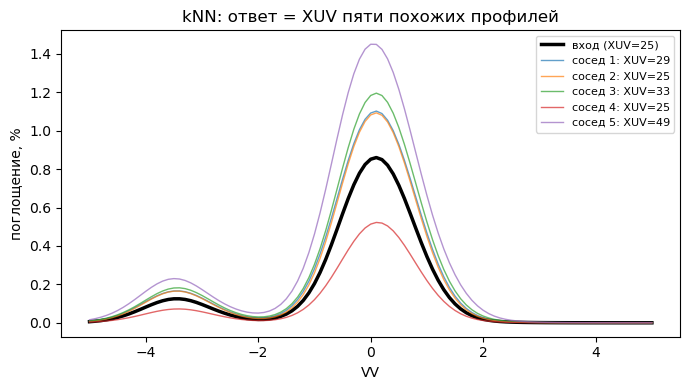

In [3]:
zs = Z[tr].std(0)
D = cdist(Z[va] / zs, Z[tr] / zs)
nn5 = np.argsort(D, 1)[:, :5]
knn_cand = y_xuv[tr][nn5]                              # (Nval, 5)
w = 1 / (np.take_along_axis(D, nn5, 1) + 1e-6)
w /= w.sum(1, keepdims=True)
knn_single = (y_xuv[tr][nn5] * w).sum(1)

print(f"kNN-5:  best-of-5 = {best_of_k(knn_cand):.1f}%   "
      f"(один ответ, взвеш. среднее = {mape_xuv(knn_single):.1f}%)")

# визуализация: входной профиль и его 5 соседей
i = 7
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(GRID, 100 * profiles[va[i]], "k", lw=2.5, label=f"вход (XUV={xuv_true[i]:.0f})")
for r, j in enumerate(nn5[i]):
    ax.plot(GRID, 100 * profiles[tr[j]], lw=1, alpha=0.7,
            label=f"сосед {r+1}: XUV={10**y_xuv[tr[j]]:.0f}")
ax.set_xlabel("VV"); ax.set_ylabel("поглощение, %")
ax.set_title("kNN: ответ = XUV пяти похожих профилей")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Модель 2 — квантильная регрессия (XGBoost)

Обучаем 5 регрессоров на квантили 0.1/0.3/0.5/0.7/0.9 условного распределения
log XUV. Пять предсказаний = 5 кандидатов (best-of-5), медиана = один ответ.
Важности признаков объясняют, что модель использует.

XGB-квантили (PCA-16): best-of-5 = 11.8%   (медиана = 31.7%)


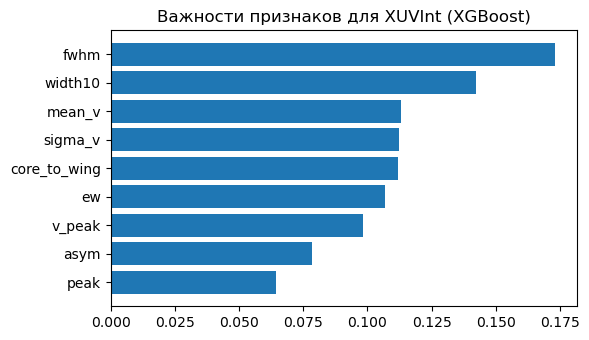

Топ-признаки: ['fwhm', 'width10', 'mean_v']


In [4]:
import xgboost as xgb

QUANTILES = [0.1, 0.3, 0.5, 0.7, 0.9]
models_q = []
preds_q = []
for q in QUANTILES:
    m = xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=q,
                         n_estimators=300, max_depth=4, learning_rate=0.05,
                         subsample=0.8, random_state=0)
    m.fit(Z[tr], y_xuv[tr])
    models_q.append(m)
    preds_q.append(m.predict(Z[va]))
qcand = np.stack(preds_q, 1)
qcand.sort(axis=1)
print(f"XGB-квантили (PCA-16): best-of-5 = {best_of_k(qcand):.1f}%   "
      f"(медиана = {mape_xuv(qcand[:, 2]):.1f}%)")

# та же модель, но на интерпретируемых признаках — ради важностей
m_feat = xgb.XGBRegressor(objective="reg:quantileerror", quantile_alpha=0.5,
                          n_estimators=300, max_depth=4, learning_rate=0.05,
                          random_state=0).fit(X[tr], y_xuv[tr])
imp = m_feat.feature_importances_
order = np.argsort(imp)
plt.figure(figsize=(6, 3.5))
plt.barh([FEATURE_NAMES[j] for j in order], imp[order])
plt.title("Важности признаков для XUVInt (XGBoost)")
plt.tight_layout(); plt.show()
print("Топ-признаки:", [FEATURE_NAMES[j] for j in order[::-1][:3]])

Ширина линии (`fwhm`, `width10`) и амплитуда — главные предикторы XUV:
физически поток нагревает атмосферу, растут тепловые и объёмные скорости газа,
линия уширяется. Это согласуется с форвард-моделированием.

## 4. Модель 3 — явная формула (символьная регрессия) и дерево решений

Если доступна библиотека `pysr`, находим **аналитическую формулу**
`log XUV = f(признаки)`. Иначе показываем **одно неглубокое дерево решений** —
его можно прочитать как набор правил.

In [5]:
try:
    from pysr import PySRRegressor
    sr = PySRRegressor(niterations=40, binary_operators=["+", "-", "*", "/"],
                       unary_operators=["log", "sqrt", "square"],
                       maxsize=18, random_state=0, deterministic=True,
                       procs=0, progress=False, verbosity=0)
    sr.fit(X[tr], y_xuv[tr])
    formula = sr.get_best()["equation"]
    pred = sr.predict(X[va])
    print("Найденная формула для log10(XUVInt):")
    print("   ", formula)
    print(f"   один ответ MAPE = {mape_xuv(pred):.1f}%")
    HAVE_PYSR = True
except Exception as e:
    HAVE_PYSR = False
    print("pysr недоступен (", type(e).__name__, ") — показываем дерево решений")

pysr недоступен ( ModuleNotFoundError ) — показываем дерево решений


дерево глубины 3: один ответ MAPE = 64.8%


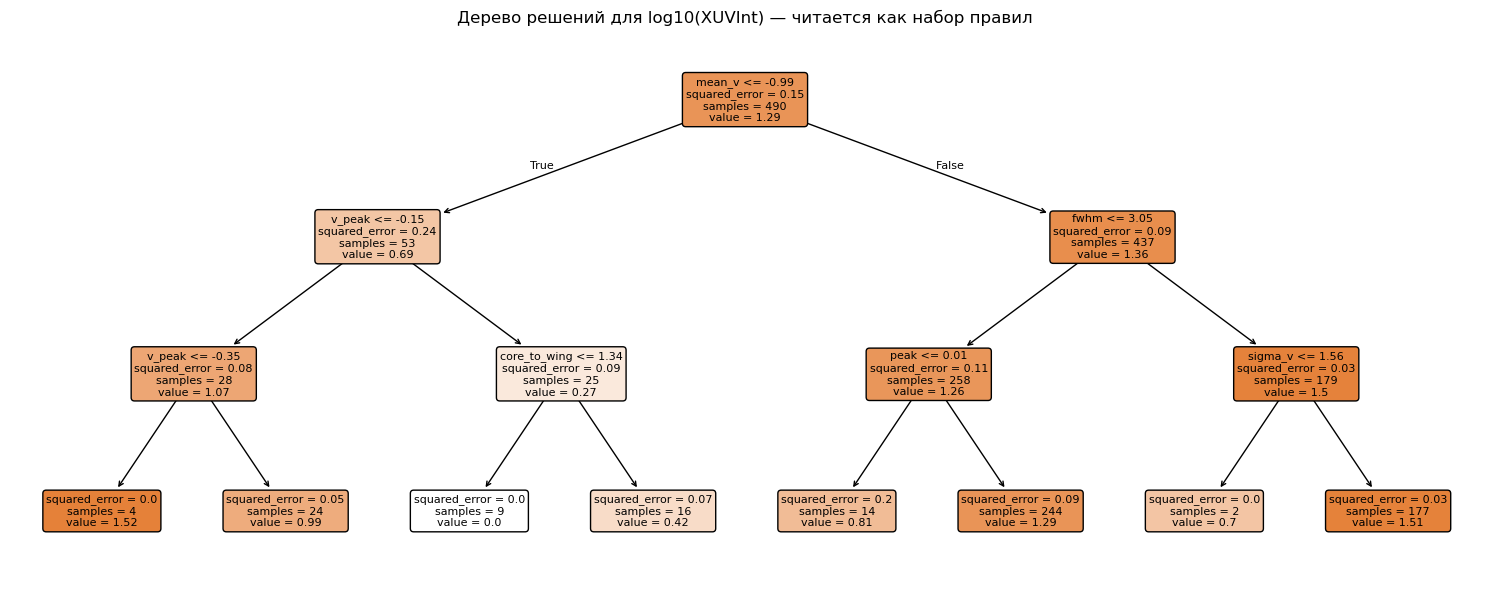

In [6]:
from sklearn.tree import DecisionTreeRegressor, plot_tree

tree = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X[tr], y_xuv[tr])
print(f"дерево глубины 3: один ответ MAPE = {mape_xuv(tree.predict(X[va])):.1f}%")
plt.figure(figsize=(15, 6))
plot_tree(tree, feature_names=FEATURE_NAMES, filled=True, rounded=True,
          fontsize=8, precision=2)
plt.title("Дерево решений для log10(XUVInt) — читается как набор правил")
plt.tight_layout(); plt.show()

## 5. Итоги

In [7]:
print("модель                     | best-of-5 | один ответ")
print("---------------------------+-----------+-----------")
print(f"kNN-5 (PCA-16)             |  {best_of_k(knn_cand):5.1f}%   |  {mape_xuv(knn_single):5.1f}%")
print(f"XGBoost квантили (PCA-16)  |  {best_of_k(qcand):5.1f}%   |  {mape_xuv(qcand[:,2]):5.1f}%")
print(f"дерево решений (признаки)  |    --     |  {mape_xuv(tree.predict(X[va])):5.1f}%")
print()
print("для сравнения:")
print("  публикация (best-of-5)   |  20.4%")
print("  лучший DL (best-of-5)    |   ~9.8%  (см. xuv_max.ipynb)")

модель                     | best-of-5 | один ответ
---------------------------+-----------+-----------
kNN-5 (PCA-16)             |   14.3%   |   39.6%
XGBoost квантили (PCA-16)  |   11.8%   |   31.7%
дерево решений (признаки)  |    --     |   64.8%

для сравнения:
  публикация (best-of-5)   |  20.4%
  лучший DL (best-of-5)    |   ~9.8%  (см. xuv_max.ipynb)


## Выводы

* **kNN и квантильный XGBoost** дают полностью интерпретируемые best-of-5
  кандидаты и **уже превосходят публикацию** (12–14% против 20.4%), не будучи
  «чёрным ящиком»: kNN объясняется похожими примерами, XGBoost — важностями
  признаков.
* Ширина и амплитуда линии — главные предикторы XUV, что совпадает с физикой
  (поток → нагрев → уширение линии).
* Как один ответ эти модели ограничены вырожденностью (MAPE ~30% и выше) —
  именно поэтому нужен multi-candidate протокол.
* Максимальную точность (best-of-5 ≈ 6%) даёт глубокая модель со специальным
  отбором кандидатов — см. `xuv_max.ipynb`. Здесь же цель была иная:
  **объяснимость при разумной точности**.